#### Install and importing lightkurve, which is NASA's official    Python library for Kepler/TESS data

In [ ]:
!pip install lightkurve
import lightkurve as lk

#### Here we have searched for a known confirmed exoplanet host star and downloaded its light curve. Kepler-10 is a good first target since it has a well-documented transit.

SearchResult containing 50 data products.

 #       mission      year   author   exptime         target_name          distance
                                         s                                  arcsec 
--- ----------------- ---- ---------- ------- ---------------------------- --------
  0 Kepler Quarter 02 2009     Kepler      60                kplr011904151      0.0
  1 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  2 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  3 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  4 Kepler Quarter 00 2009     Kepler    1800                kplr011904151      0.0
  5 Kepler Quarter 01 2009     Kepler    1800                kplr011904151      0.0
  6 Kepler Quarter 02 2009     Kepler    1800                kplr011904151      0.0
  7 Kepler Quarter 03 2009     Kepler    1800                kplr011904151      0.0
  8 Kepler Quarter 04 2010     Ke

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

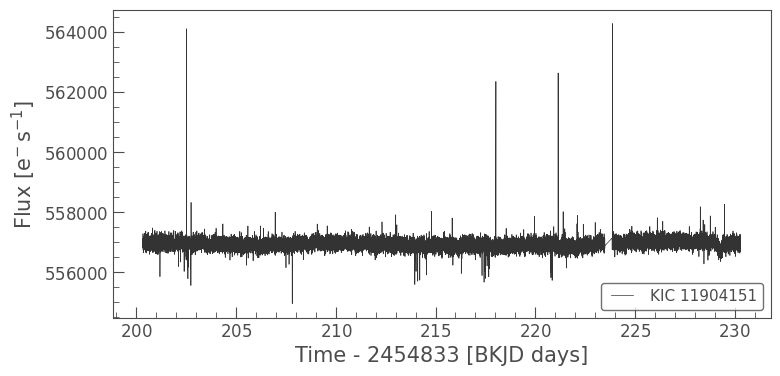

In [ ]:
search_result = lk.search_lightcurve('Kepler-10', mission='Kepler')
print(search_result)
lc = search_result[0].download()
lc.plot()

#### Flattening and folding the light curve at its known period (Kepler-10 b has a period of about 0.84 days) to see the actual transit dip.

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

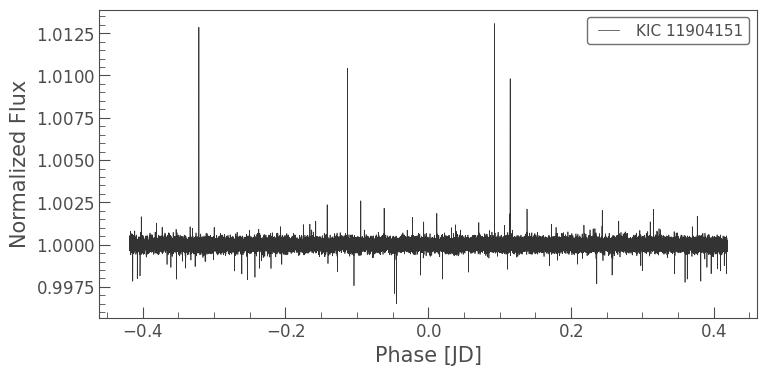

In [ ]:
flat_lc = lc.flatten()
folded = flat_lc.fold(period=0.8375)
folded.plot()

### Loading the master NASA Exoplanet Archive dataset and extracting a target shortlist of 10 specific star IDs (5 confirmed planets and 5 false positives) to prepare our training data.

In [9]:
import pandas as pd

koi = pd.read_csv('koi_table.csv', comment='#')

print(koi['koi_disposition'].value_counts())

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2747
CANDIDATE         1978
Name: count, dtype: int64


In [10]:
print("--- 5 CONFIRMED PLANETS ---")
print(koi[koi['koi_disposition'] == 'CONFIRMED']['kepid'].head(5).to_string(index=False))

print("\n--- 5 FALSE POSITIVES ---")
print(koi[koi['koi_disposition'] == 'FALSE POSITIVE']['kepid'].head(5).to_string(index=False))

--- 5 CONFIRMED PLANETS ---
10797460
10797460
10854555
10872983
10872983

--- 5 FALSE POSITIVES ---
10848459
 6721123
10419211
10464078
10480982
